# INF421 — Équation Eikonale et Planification de Chemin

**Membres**

- KAMDEM POUOKAM Ivann Harold — **PC**
- NGANTA Pacifique — **PC**

---

Ce notebook présente la résolution de l'équation Eikonale et son application à la planification de chemin optimal dans des milieux à vitesse variable.

### Installation du projet

In [7]:
!pip install uv


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import os
import sys

# Add src to path for local development
if os.path.exists("src/eikonale_explorer"):
    sys.path.insert(0, "src")
    !uv pip install -e . --quiet
else:
    # Install from GitHub if not local
    !uv pip install git+https://www.github.com/KpihX/random-explorer.git#subdirectory=eikonale-explorer --quiet

### Chargement des données (mêmes scénarios que random-explorer)

In [9]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np

# Download all scenarios from Kaggle
SCENARIOS = {}
for i in range(5):
    file = f"scenario{i}.txt"
    path = kagglehub.dataset_download(
        handle="ivannkamdem/random-explorer",
        path=file,
    )
    SCENARIOS[f"scenario{i}"] = path
    print(f"Loaded: {file} -> {path}")

# Default scenario
file_path = SCENARIOS["scenario0"]

Loaded: scenario0.txt -> /home/kpihx/.cache/kagglehub/datasets/ivannkamdem/random-explorer/versions/1/scenario0.txt
Loaded: scenario1.txt -> /home/kpihx/.cache/kagglehub/datasets/ivannkamdem/random-explorer/versions/1/scenario1.txt
Loaded: scenario2.txt -> /home/kpihx/.cache/kagglehub/datasets/ivannkamdem/random-explorer/versions/1/scenario2.txt
Loaded: scenario3.txt -> /home/kpihx/.cache/kagglehub/datasets/ivannkamdem/random-explorer/versions/1/scenario3.txt
Loaded: scenario4.txt -> /home/kpihx/.cache/kagglehub/datasets/ivannkamdem/random-explorer/versions/1/scenario4.txt


In [10]:
# Import du package eikonale_explorer
from eikonale_explorer import (
    Environment,
    LaxFriedrichsSolver,
    PathFinder,
    IndexConfig,
    create_uniform_index,
    create_diopter_index,
    create_gaussian_index,
    create_obstacle_index,
    create_island_index,
    plot_contour_lines,
    plot_index_map,
    plot_path,
    plot_comparison,
    console,
)

plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

---

# Partie 1 : Résolution de l'équation Eikonale

---

On résout l'équation Eikonale sur $\phi$ avec le schéma numérique de **Lax-Friedrichs**.

On maille le domaine $\Omega=[0,1]^2$ avec un pas $h$ constant.

Le schéma de Lax-Friedrichs s'écrit :

$$\phi_{ij}^{p+1} = \frac{\phi_{i+1,j} + \phi_{i-1,j} + \phi_{i,j+1} + \phi_{i,j-1}}{4} - \Delta t \cdot H(\nabla \phi_{ij}, N_{ij})$$

avec $H(\nabla\phi, N) = |\nabla\phi| - N$ le Hamiltonien de l'équation Eikonale.

## Question 1 : Implémentation du schéma

Le solveur `LaxFriedrichsSolver` est implémenté dans le module `solvers/lax_friedrichs.py`.

Paramètres :
- $\Delta t = h/2$
- $h = 1/64$ (puis on réduira)
- Critère d'arrêt : $\|\phi^{p+1} - \phi^p\|_\infty < \text{TOL}$

## Question 2 : Cas $N(x,y) = 1$ (indice uniforme)

Avec un indice uniforme, les lignes de niveau de $\phi$ doivent être des **cercles** centrés sur la source.

In [11]:
# Paramètres
h = 1/64
dt = h/2
nx = int(1/h)
print(f"Grille: {nx}x{nx}, h={h:.4f}")

# Source
source = (0.4, 0.5)
depart = (int(source[0]/h), int(source[1]/h))
print(f"Source: {source} -> indices {depart}")

# Indice uniforme N=1
config = IndexConfig(nx=nx, ny=nx)
N_uniform = create_uniform_index(config, value=1.0)

# Résolution
solver = LaxFriedrichsSolver(max_iter=2000, tol=1e-9)
phi_uniform = solver.solve(N_uniform, source, h, show_progress=True)

Grille: 64x64, h=0.0156
Source: (0.4, 0.5) -> indices (25, 32)


Lax-Friedrichs Eikonal:   0%|          | 0/2000 [00:00<?, ?it/s]

✓ Converged difference 9.30e-10 < 1e-09 at iter 271

Lax-Friedrichs Eikonal:  14%|█▎        | 271/2000 [00:00<00:00, 13937.81it/s]


<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1430692/3696210384.py:4: SyntaxWarning: invalid escape sequence '\p'
  title="Q2: Lignes de niveau de $\phi$ (N=1, cercles attendus)")


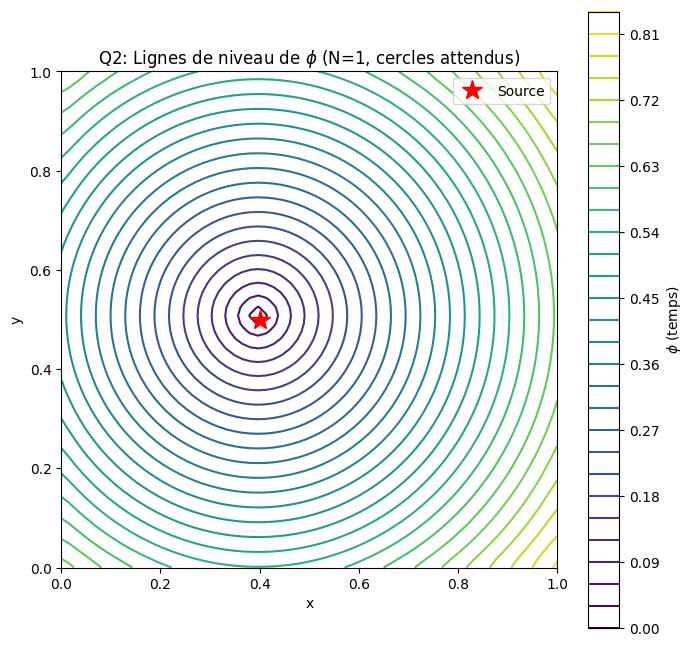

In [12]:
# Visualisation
fig, ax = plt.subplots(figsize=(8, 8))
plot_contour_lines(phi_uniform, source, ax=ax, 
                   title="Q2: Lignes de niveau de $\phi$ (N=1, cercles attendus)")
plt.show()

## Question 3 : Cas du dioptre (mer/plage)

L'indice est différent dans deux parties du domaine :

$$N(x,y) = \begin{cases} 1 & \text{si } y \leq 0.5 \\ 10 & \text{si } y > 0.5 \end{cases}$$

Cela modélise une plage (vitesse rapide, $N=1$) et la mer (vitesse lente, $N=10$).
Les lignes de niveau se "cassent" à l'interface (loi de Snell-Descartes).

Lax-Friedrichs Eikonal:   0%|          | 0/2000 [00:00<?, ?it/s]

✓ Converged difference 8.93e-10 < 1e-09 at iter 404

Lax-Friedrichs Eikonal:  20%|██        | 404/2000 [00:00<00:00, 14052.67it/s]


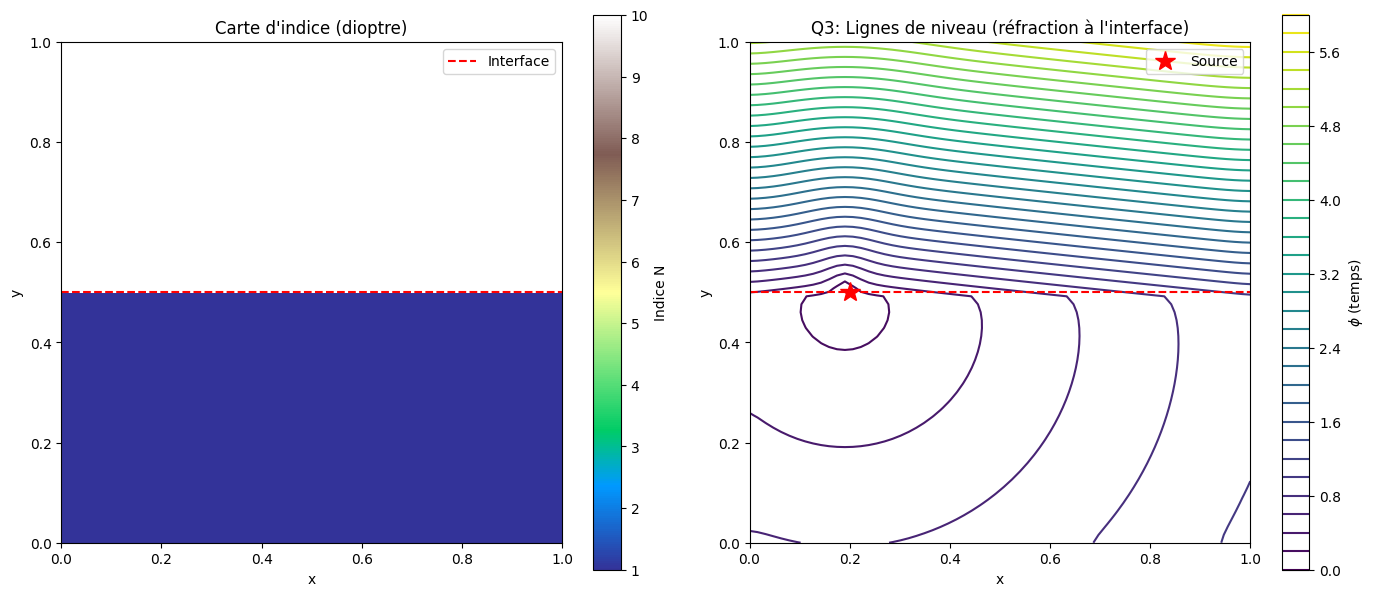

In [13]:
# Dioptre
source_dioptre = (0.2, 0.5)
N_dioptre = create_diopter_index(config, boundary=0.5, 
                                  index_low=1.0, index_high=10.0, axis='y')

solver = LaxFriedrichsSolver(max_iter=2000, tol=1e-9)
phi_dioptre = solver.solve(N_dioptre, source_dioptre, h, show_progress=True)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Carte d'indice
plot_index_map(N_dioptre, ax=axes[0], log_scale=False, 
               title="Carte d'indice (dioptre)")
axes[0].axhline(y=0.5, color='red', linestyle='--', label='Interface')
axes[0].legend()

# Lignes de niveau
plot_contour_lines(phi_dioptre, source_dioptre, ax=axes[1],
                   title="Q3: Lignes de niveau (réfraction à l'interface)")
axes[1].axhline(y=0.5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## Question 4 : Cas de l'indice gaussien

$$N(x,y) = 1 + \sigma \exp\left(-50(x-l_x)^2 - 100(y-l_y)^2\right)$$

avec $\sigma=1.5$, $l_x=0.6$, $l_y=0.5$.

Les lignes de niveau sont plus resserrées là où $N$ est plus grand.

Lax-Friedrichs Eikonal:   0%|          | 0/2000 [00:00<?, ?it/s]

✓ Converged difference 9.08e-10 < 1e-09 at iter 312

Lax-Friedrichs Eikonal:  16%|█▌        | 312/2000 [00:00<00:00, 16957.44it/s]


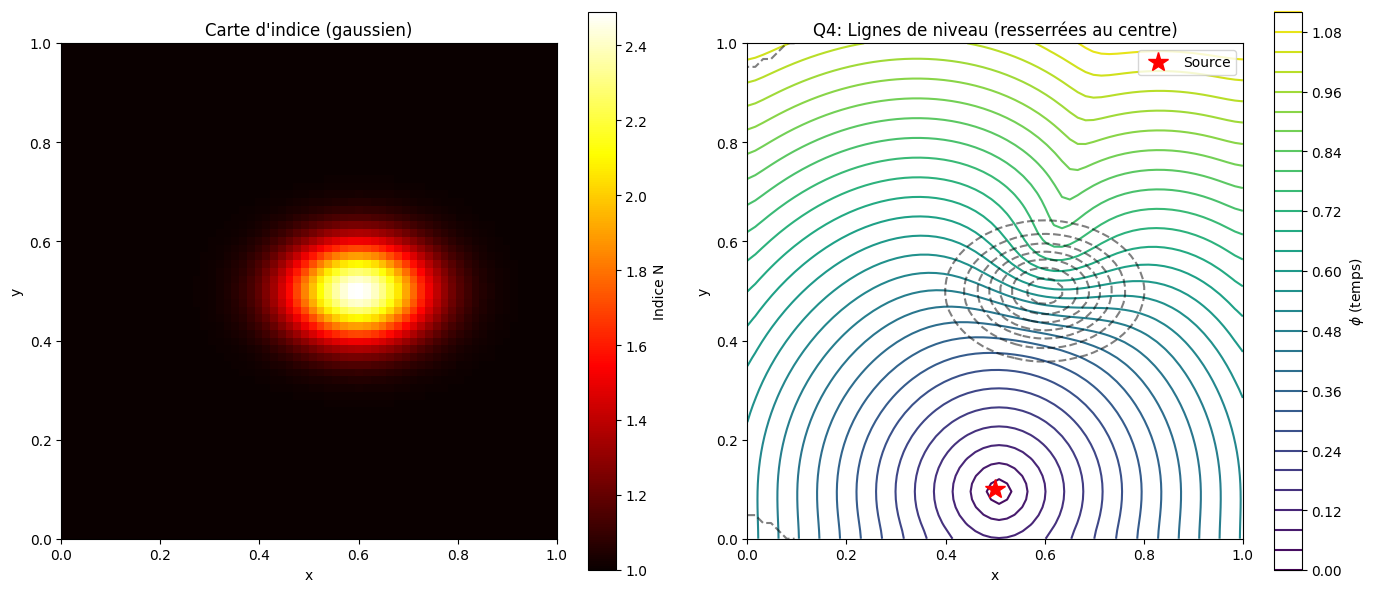

In [14]:
# Gaussien
source_gauss = (0.5, 0.1)
N_gauss = create_gaussian_index(config, center=(0.6, 0.5),
                                 sigma_x=50.0, sigma_y=100.0,
                                 amplitude=1.5, base_index=1.0)

solver = LaxFriedrichsSolver(max_iter=2000, tol=1e-9)
phi_gauss = solver.solve(N_gauss, source_gauss, h, show_progress=True)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_index_map(N_gauss, ax=axes[0], log_scale=False, cmap='hot',
               title="Carte d'indice (gaussien)")

plot_contour_lines(phi_gauss, source_gauss, ax=axes[1],
                   title="Q4: Lignes de niveau (resserrées au centre)")

# Superposer contours de N
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x, y)
axes[1].contour(X, Y, N_gauss, colors='k', linestyles='--', alpha=0.5)

plt.tight_layout()
plt.show()

---

# Partie 2 : Calcul de Chemins

---

## Rayons lumineux

À partir de la solution $\phi$, on reconstruit le trajet le plus court reliant deux points.

$\phi(X)$ représente le temps mis par un rayon pour atteindre $X$ depuis la source.

Les rayons suivent l'équation différentielle :

$$\frac{dX}{dt} = -\frac{\nabla\phi(X)}{|\nabla\phi(X)|}$$

On peut vérifier que $\frac{d}{dt}\phi(X(t)) = -1$, donc on "remonte le temps" à vitesse constante.

## Question 2 : Interpolation du gradient

Pour calculer $\nabla\phi$ en tout point $(x,y)$, on utilise une **interpolation bilinéaire** basée sur les 4 voisins de la grille.

Implémentation : voir `path_finder.interpolate_gradient()`

## Question 3 : Schémas d'Euler et Heun

### Euler explicite (ordre 1)
$$X_{n+1} = X_n + \Delta t \cdot f(X_n)$$

### Heun (Runge-Kutta 2, ordre 2)
$$\tilde{X} = X_n + \Delta t \cdot f(X_n)$$
$$X_{n+1} = X_n + \frac{\Delta t}{2}\left(f(X_n) + f(\tilde{X})\right)$$

Heun est plus précis car il utilise une étape de correction.

In [23]:
# Test sur le cas uniforme
h = 1/128
nx = int(1/h)
config = IndexConfig(nx=nx, ny=nx)

source = (0.3, 0.6)
goal = (0.9, 0.1)

N_test = create_uniform_index(config, value=1.0)

solver = LaxFriedrichsSolver(max_iter=1000, tol=1e-8)
phi_test = solver.solve(N_test, source, h, show_progress=True)

# Reconstruction avec Euler et Heun
path_euler = PathFinder.solve_euler(phi_test, N_test, source, goal, h)
path_heun = PathFinder.solve_heun(phi_test, source, goal, h)

print(f"Euler: {len(path_euler)} points")
print(f"Heun:  {len(path_heun)} points")

Lax-Friedrichs Eikonal:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ Converged difference 9.41e-09 < 1e-08 at iter 419

Lax-Friedrichs Eikonal:  42%|████▏     | 419/1000 [00:00<00:00, 5618.51it/s]


Euler: 10001 points
Heun:  10001 points


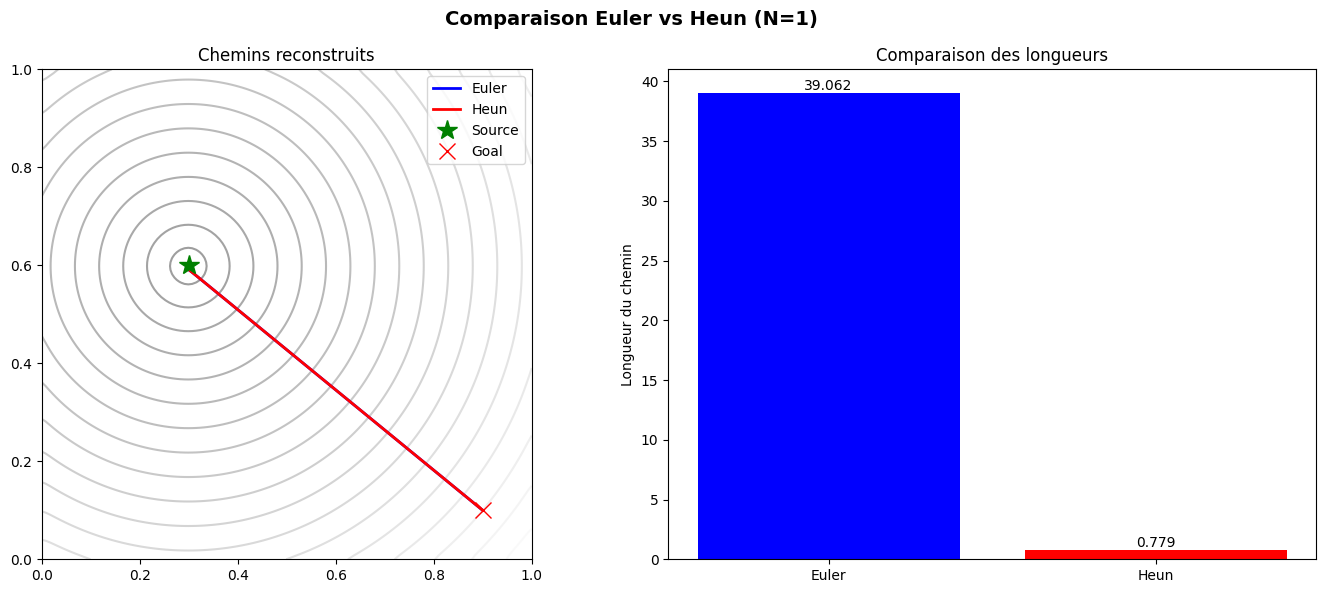

In [24]:
# Comparaison visuelle
paths = {'Euler': path_euler, 'Heun': path_heun}
fig = plot_comparison(phi_test, paths, source, goal, N_test,
                      title="Comparaison Euler vs Heun (N=1)")
plt.show()

Lax-Friedrichs Eikonal:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ Converged difference 7.92e-09 < 1e-08 at iter 303

Lax-Friedrichs Eikonal:  30%|███       | 303/1000 [00:00<00:00, 12624.41it/s]


⚠ Euler: Path left domain at step 0

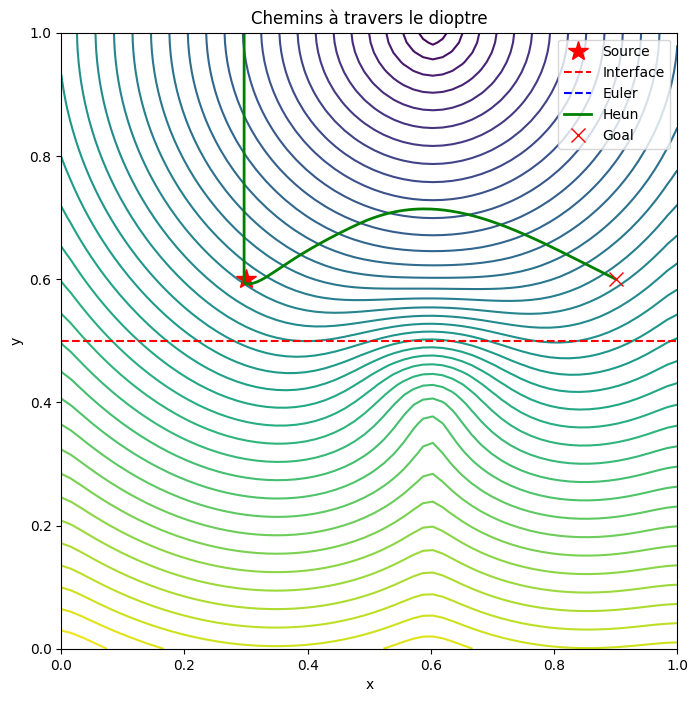

In [25]:
# Test avec dioptre
N_dioptre = N_gauss
#N_dioptre = create_diopter_index(config, boundary=0.5, index_low=1.0, index_high=10.0)

phi_dioptre = solver.solve(N_dioptre, source, h, show_progress=True)
goal = (0.9, 0.6)
path_euler_d = PathFinder.solve_euler(phi_dioptre, N_dioptre, source, goal, h)
path_heun_d = PathFinder.solve_heun(phi_dioptre, source, goal, h)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
plot_contour_lines(phi_dioptre, source, ax=ax, levels=40, add_colorbar=False)
ax.axhline(y=0.5, color='red', linestyle='--', label='Interface')

if len(path_euler_d) > 0:
    ax.plot(path_euler_d[:,0], path_euler_d[:,1], 'b--', lw=1.5, label='Euler')
if len(path_heun_d) > 0:
    ax.plot(path_heun_d[:,0], path_heun_d[:,1], 'g-', lw=2, label='Heun')

ax.plot(goal[0], goal[1], 'rx', markersize=10, label='Goal')
ax.legend()
ax.set_title("Chemins à travers le dioptre")
plt.show()

---

# Partie 3 : Pour aller plus loin

---

## Obstacles

Les obstacles sont des régions où l'indice est **très grand** (quasi-infini).
Les trajectoires les contournent automatiquement.

In [26]:
# Obstacle rectangulaire au centre
h = 1/128
nx = int(1/h)
config = IndexConfig(nx=nx, ny=nx)

# Définition de l'obstacle (comme dans le TP original)
lx, ly = 0.15, 0.1  # demi-dimensions
center = (0.5, 0.5)
obstacle = [(center[0]-lx, center[1]-ly, 2*lx, 2*ly)]

N_obstacle = create_obstacle_index(config, obstacle,
                                   base_index=1.0, obstacle_index=1e6)

source = (0.3, 0.6)
goal = (0.9, 0.4)

solver = LaxFriedrichsSolver(max_iter=1500, tol=1e-7)
phi_obs = solver.solve(N_obstacle, source, h, show_progress=True)

path_obs = PathFinder.solve_heun(phi_obs, source, goal, h)

Lax-Friedrichs Eikonal:   0%|          | 0/1500 [00:00<?, ?it/s]

✓ Converged difference 9.40e-08 < 1e-07 at iter 439

Lax-Friedrichs Eikonal:  29%|██▉       | 439/1500 [00:00<00:00, 6525.54it/s]


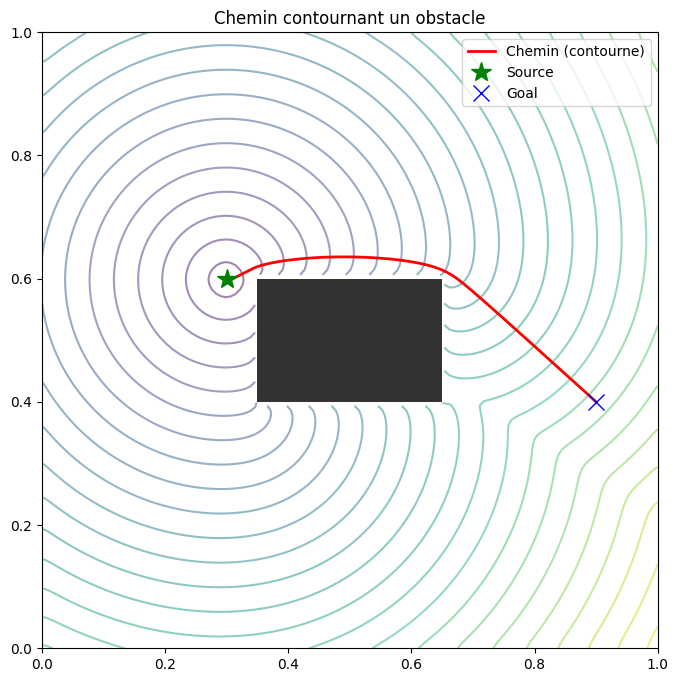

In [27]:
# Visualisation
from eikonale_explorer import plot_obstacles

fig, ax = plt.subplots(figsize=(10, 8))

# Contours de phi
phi_masked = np.ma.masked_where(N_obstacle > 100, phi_obs)
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x, y)
ax.contour(X, Y, phi_masked, levels=30, cmap='viridis', alpha=0.5)

# Obstacle
plot_obstacles(obstacle, ax=ax, facecolor='black', alpha=0.8)

# Chemin
if len(path_obs) > 0:
    ax.plot(path_obs[:,0], path_obs[:,1], 'r-', lw=2, label='Chemin (contourne)')

ax.plot(source[0], source[1], 'g*', markersize=15, label='Source')
ax.plot(goal[0], goal[1], 'bx', markersize=12, label='Goal')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.legend()
ax.set_title("Chemin contournant un obstacle")
plt.show()

## L'île

Terrain complexe avec différentes zones :
- **Forêt** : indice = 1 (rapide)
- **Plage** : indice = 2
- **Montagne** : indice = 10 (lent)
- **Rivière** : indice = $10^7$ (quasi-infranchissable)
- **Mer** : indice = $10^{10}$ (infranchissable)
- **Pont** : permet de traverser la rivière

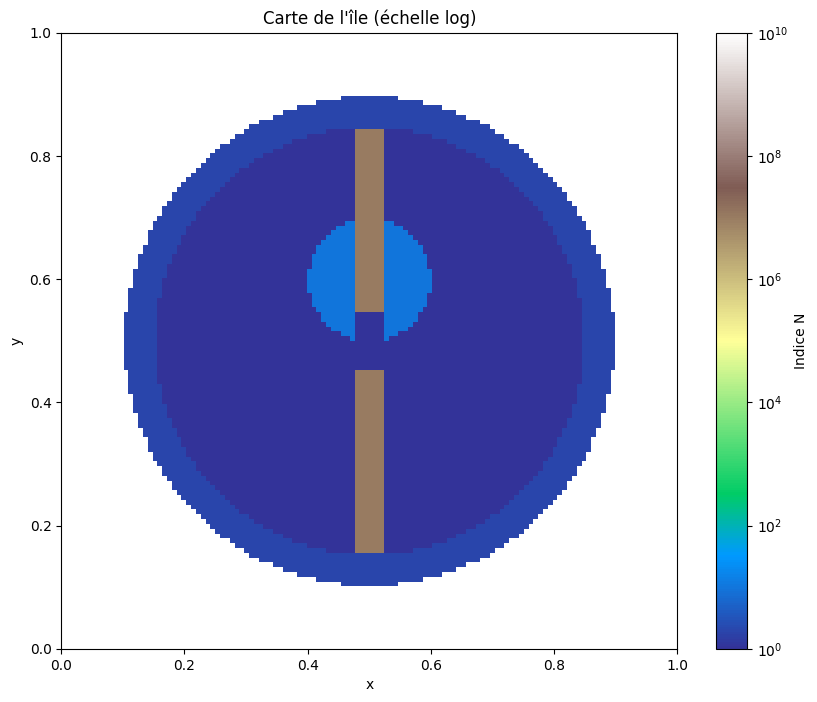

In [28]:
# Carte de l'île
h = 1/128
nx = int(1/h)
config = IndexConfig(nx=nx, ny=nx)

N_island = create_island_index(config)

fig, ax = plt.subplots(figsize=(10, 8))
plot_index_map(N_island, ax=ax, log_scale=True, cmap='terrain',
               title="Carte de l'île (échelle log)")
plt.show()

Lax-Friedrichs Eikonal: 100%|██████████| 2000/2000 [00:00<00:00, 6388.25it/s]


✓ Heun: Reached source in 100 steps

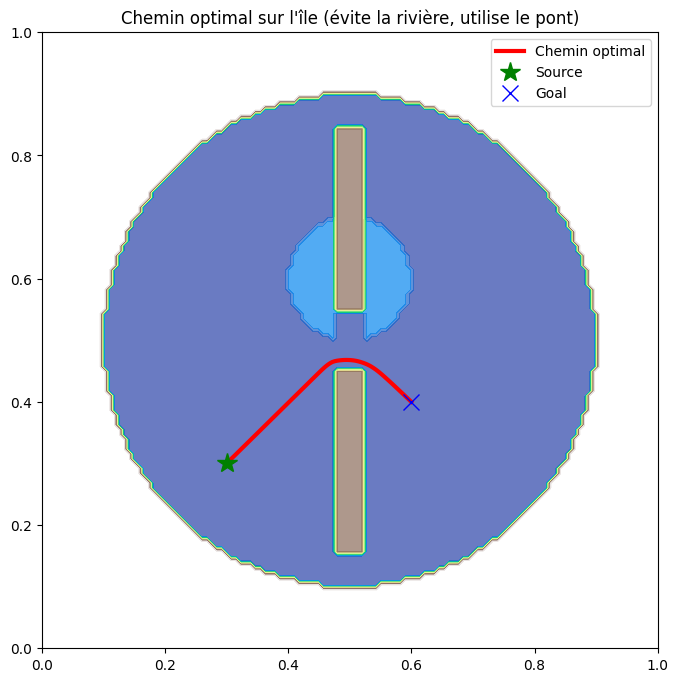

In [29]:
# Chemin sur l'île
source_ile = (0.3, 0.3)
goal_ile = (0.6, 0.4)

solver = LaxFriedrichsSolver(max_iter=2000, tol=1e-8)
phi_island = solver.solve(N_island, source_ile, h, show_progress=True)

path_island = PathFinder.solve_heun(phi_island, source_ile, goal_ile, h)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))

phi_masked = np.ma.masked_where(N_island > 100, phi_island)
ax.contourf(X, Y, np.log10(N_island + 1), levels=20, cmap='terrain', alpha=0.7)

if len(path_island) > 0:
    ax.plot(path_island[:,0], path_island[:,1], 'r-', lw=3, label='Chemin optimal')

ax.plot(source_ile[0], source_ile[1], 'g*', markersize=15, label='Source')
ax.plot(goal_ile[0], goal_ile[1], 'bx', markersize=12, label='Goal')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.legend()
ax.set_title("Chemin optimal sur l'île (évite la rivière, utilise le pont)")
plt.show()

---

# Partie 4 : Application aux scénarios

---

On utilise les mêmes fichiers de scénario que `random-explorer` pour définir les obstacles.

In [33]:
# Charger un scénario
env = Environment(SCENARIOS["scenario4"])

print(f"Dimensions: {env.width} x {env.height}")
print(f"Start: {env.start}")
print(f"Goal: {env.goal}")
print(f"Obstacles: {len(env.obstacles)}")

✓ Parsed: scenario4.txt (11 obstacles, 1000.0x1000.0)

Dimensions: 1000.0 x 1000.0
Start: (0.0, 0.0)
Goal: (1000.0, 1000.0)
Obstacles: 11


In [34]:
# Générer la carte d'indice depuis les obstacles du scénario
h_scen = env.width / 200  # résolution adaptive
nx_scen = int(env.width / h_scen)
ny_scen = int(env.height / h_scen)

N_scenario = env.get_refractive_index_map(nx_scen, ny_scen, 
                                          base_index=1.0, 
                                          obstacle_index=1e5)

print(f"Grille: {nx_scen}x{ny_scen}")

# Normaliser source/goal vers [0,1] pour le solveur
source_norm = (env.start[0]/env.width, env.start[1]/env.height)
goal_norm = (env.goal[0]/env.width, env.goal[1]/env.height)

# Résolution
solver = LaxFriedrichsSolver(max_iter=3000, tol=1e-6)
h_norm = 1.0 / nx_scen
phi_scenario = solver.solve(N_scenario, source_norm, h_norm, show_progress=True)

Grille: 200x200


Lax-Friedrichs Eikonal:  33%|███▎      | 978/3000 [00:00<00:00, 3264.93it/s]

✓ Converged difference 9.60e-07 < 1e-06 at iter 1180

Lax-Friedrichs Eikonal:  39%|███▉      | 1180/3000 [00:00<00:00, 3240.93it/s]


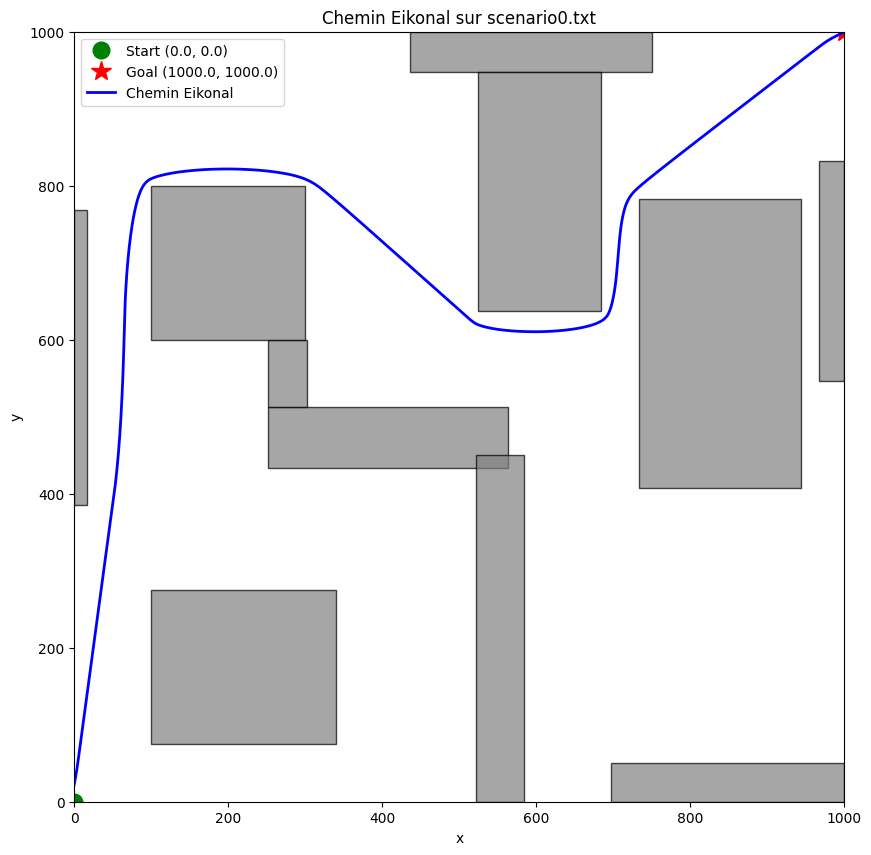

In [35]:
# Reconstruction du chemin
path_scenario = PathFinder.solve_heun(phi_scenario, source_norm, goal_norm, h_norm)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 10))

# Afficher l'environnement
env.plot(ax=ax, show=False)

# Superposer le chemin (dé-normalisé)
if len(path_scenario) > 0:
    path_denorm = path_scenario * np.array([env.width, env.height])
    ax.plot(path_denorm[:,0], path_denorm[:,1], 'b-', lw=2, label='Chemin Eikonal')

ax.legend()
ax.set_title(f"Chemin Eikonal sur {SCENARIOS['scenario0'].split('/')[-1]}")
plt.show()

---

## Conclusion

L'équation Eikonale permet de calculer des chemins optimaux dans des milieux à vitesse variable.
Contrairement aux méthodes par échantillonnage (RRT*) ou par essaims (PSO), cette approche :

- Calcule un **champ global** de distances/temps
- Permet d'extraire le chemin vers **n'importe quelle destination**
- Gère naturellement les variations continues de vitesse

Limitations :
- Complexité mémoire $O(n^2)$ pour la grille
- Moins adapté aux très hautes dimensions

---